# 🎯 Notebook 2 — Feature Selection

**Goal:** Identify which columns actually matter for predicting `Refill_Required`.
Remove useless features, keep only what helps the model.

**Steps:**
1. Correlation analysis — which features correlate with target
2. Feature importance using Random Forest
3. Remove low-importance and redundant features
4. Final feature list for ML training
5. Save selected features list

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/clean_data.csv', parse_dates=['Date'])
print(f'Loaded {len(df)} rows, {df.shape[1]} columns ✅')

Matplotlib is building the font cache; this may take a moment.


Loaded 5189 rows, 32 columns ✅


## Step 1 — Which features are available for ML?

In [2]:
# Columns we CANNOT use for training (they leak future info or are identifiers)
DROP_COLS = [
    'Date',             # identifier — use extracted features instead
    'Day',              # string — use Day_Num instead
    'Refill_Required',  # original string target — use Target (0/1)
    'Target',           # this IS our target, not a feature
    'Closing_Stock',    # LEAKS the answer — closing < 2000 = refill!
    'Stock_Ratio',      # same as Closing_Stock, leaks answer
    'Dip',              # derived from Closing_Stock — leaks answer
]

# All remaining columns are candidate features
candidate_features = [c for c in df.columns if c not in DROP_COLS]

print('Candidate features for ML:')
for i, f in enumerate(candidate_features, 1):
    print(f'  {i:2d}. {f}')

Candidate features for ML:
   1. Opening_Stock
   2. MS_Sold
   3. HSD1_Sold
   4. HSD2_Sold
   5. HSD3_Sold
   6. Total_Sold
   7. Cash
   8. Online
   9. Card
  10. Year
  11. Month
  12. DayOfWeek
  13. DayOfYear
  14. WeekOfYear
  15. Quarter
  16. Is_Weekend
  17. Day_Num
  18. Rolling_7d_Sales
  19. Rolling_3d_Sales
  20. Prev_Closing
  21. Prev_Total_Sold
  22. Days_Since_Refill
  23. Is_Festival_Month
  24. Is_Monsoon_Month
  25. Is_Summer_Month


## Step 2 — Correlation with Target

Correlation with Target (Refill_Required):
Days_Since_Refill   -0.8795
Opening_Stock       -0.8332
Prev_Closing         0.4269
Total_Sold           0.1487
HSD1_Sold            0.1446
Cash                 0.1395
HSD2_Sold            0.1389
Online               0.1360
Card                 0.1298
MS_Sold              0.1293
HSD3_Sold            0.1163
Rolling_7d_Sales     0.1100
Rolling_3d_Sales     0.1086
Prev_Total_Sold      0.1068
DayOfWeek            0.0964
Day_Num              0.0964
Is_Weekend           0.0774
Is_Monsoon_Month    -0.0733
Year                 0.0673
Is_Festival_Month    0.0518
Is_Summer_Month      0.0407
Quarter              0.0067
WeekOfYear           0.0054
DayOfYear            0.0031
Month                0.0029


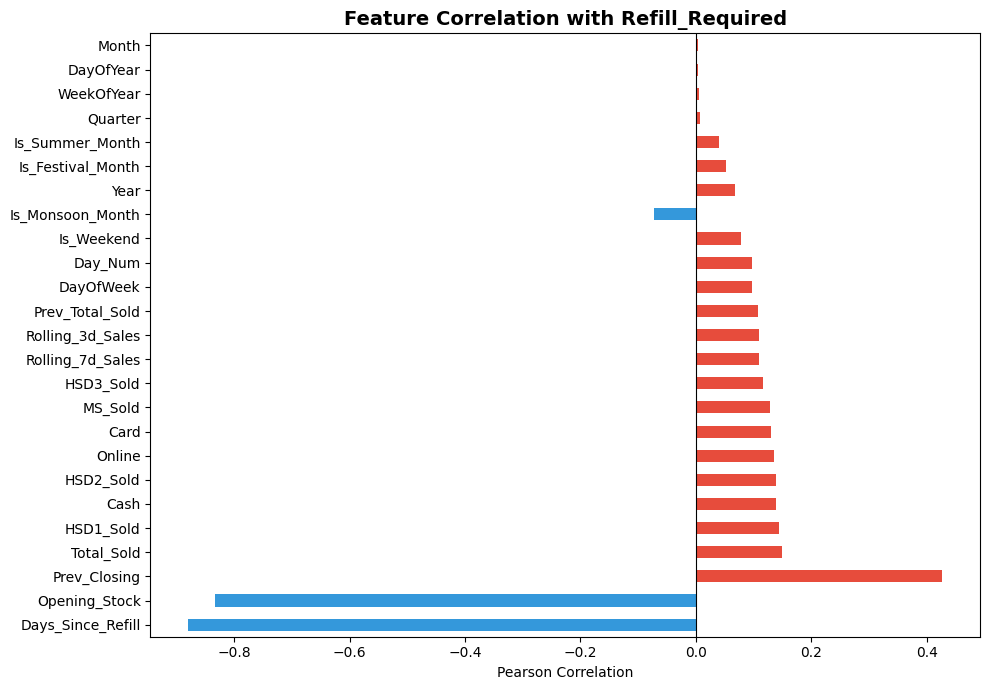

Plot saved ✅


In [3]:
# Compute correlation of each feature with Target
X_corr = df[candidate_features].copy()
X_corr['Target'] = df['Target']

correlations = X_corr.corr()['Target'].drop('Target').sort_values(key=abs, ascending=False)

print('Correlation with Target (Refill_Required):')
print(correlations.round(4).to_string())

# Plot
plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in correlations]
correlations.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Refill_Required', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../data/correlation_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✅')

## Step 3 — Random Forest Feature Importance

Feature Importances (Random Forest):
  Days_Since_Refill         0.4432  ████████████████████████████████████████████
  Opening_Stock             0.3111  ███████████████████████████████
  Prev_Closing              0.1853  ██████████████████
  HSD1_Sold                 0.0116  █
  Total_Sold                0.0116  █
  Rolling_3d_Sales          0.0073  
  Prev_Total_Sold           0.0069  
  HSD2_Sold                 0.0061  
  Cash                      0.0061  
  Rolling_7d_Sales          0.0017  
  HSD3_Sold                 0.0016  
  DayOfWeek                 0.0014  
  Online                    0.0013  
  MS_Sold                   0.0013  
  Card                      0.0011  
  Day_Num                   0.0006  
  DayOfYear                 0.0005  
  Year                      0.0004  
  WeekOfYear                0.0004  
  Month                     0.0002  
  Is_Summer_Month           0.0001  
  Quarter                   0.0001  
  Is_Weekend                0.0001  
  Is_Festival_Mon

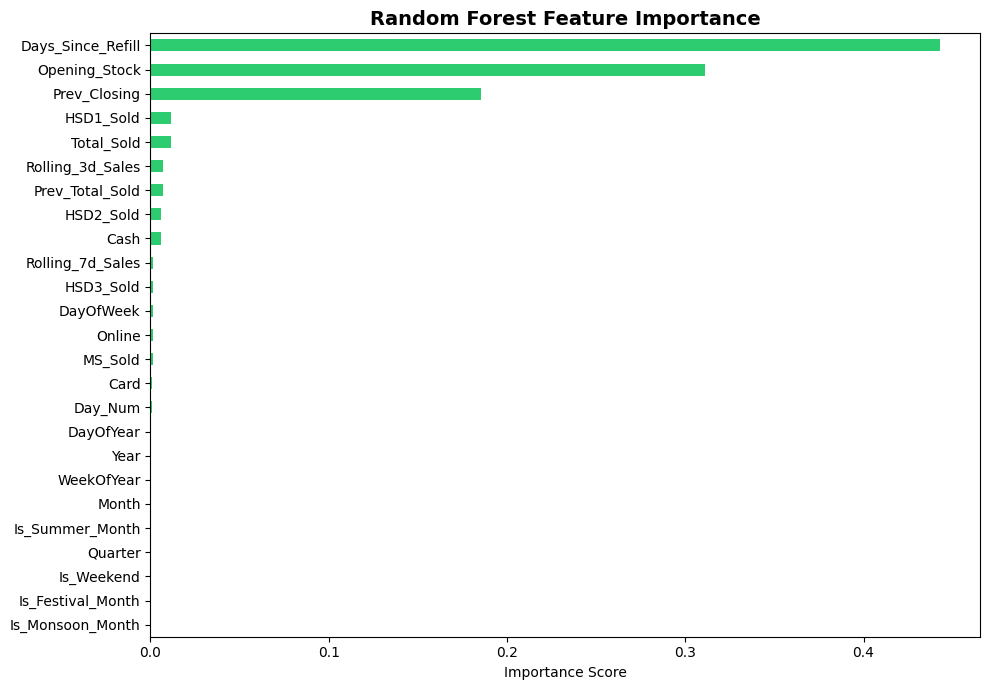

In [4]:
X = df[candidate_features].fillna(0)
y = df['Target']

# Quick RF to get feature importances
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=candidate_features)
importances = importances.sort_values(ascending=False)

print('Feature Importances (Random Forest):')
for feat, imp in importances.items():
    bar = '█' * int(imp * 100)
    print(f'  {feat:<25} {imp:.4f}  {bar}')

# Plot
plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='#2ecc71')
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/feature_importance_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Select Final Features

In [6]:
# Keep features with importance > 0.01 (1%)
IMPORTANCE_THRESHOLD = 0.01
selected = importances[importances >= IMPORTANCE_THRESHOLD].index.tolist()

print(f'Features above {IMPORTANCE_THRESHOLD*100:.0f}% importance threshold:')
for f in selected:
    print(f'  ✅ {f}  (importance: {importances[f]:.4f})')

dropped = [f for f in candidate_features if f not in selected]
print(f'\nDropped (low importance):')
for f in dropped:
    print(f'  ❌ {f}  (importance: {importances[f]:.4f})')

Features above 1% importance threshold:
  ✅ Days_Since_Refill  (importance: 0.4432)
  ✅ Opening_Stock  (importance: 0.3111)
  ✅ Prev_Closing  (importance: 0.1853)
  ✅ HSD1_Sold  (importance: 0.0116)
  ✅ Total_Sold  (importance: 0.0116)

Dropped (low importance):
  ❌ MS_Sold  (importance: 0.0013)
  ❌ HSD2_Sold  (importance: 0.0061)
  ❌ HSD3_Sold  (importance: 0.0016)
  ❌ Cash  (importance: 0.0061)
  ❌ Online  (importance: 0.0013)
  ❌ Card  (importance: 0.0011)
  ❌ Year  (importance: 0.0004)
  ❌ Month  (importance: 0.0002)
  ❌ DayOfWeek  (importance: 0.0014)
  ❌ DayOfYear  (importance: 0.0005)
  ❌ WeekOfYear  (importance: 0.0004)
  ❌ Quarter  (importance: 0.0001)
  ❌ Is_Weekend  (importance: 0.0001)
  ❌ Day_Num  (importance: 0.0006)
  ❌ Rolling_7d_Sales  (importance: 0.0017)
  ❌ Rolling_3d_Sales  (importance: 0.0073)
  ❌ Prev_Total_Sold  (importance: 0.0069)
  ❌ Is_Festival_Month  (importance: 0.0000)
  ❌ Is_Monsoon_Month  (importance: 0.0000)
  ❌ Is_Summer_Month  (importance: 0.0001)


## Step 5 — Check for Multicollinearity

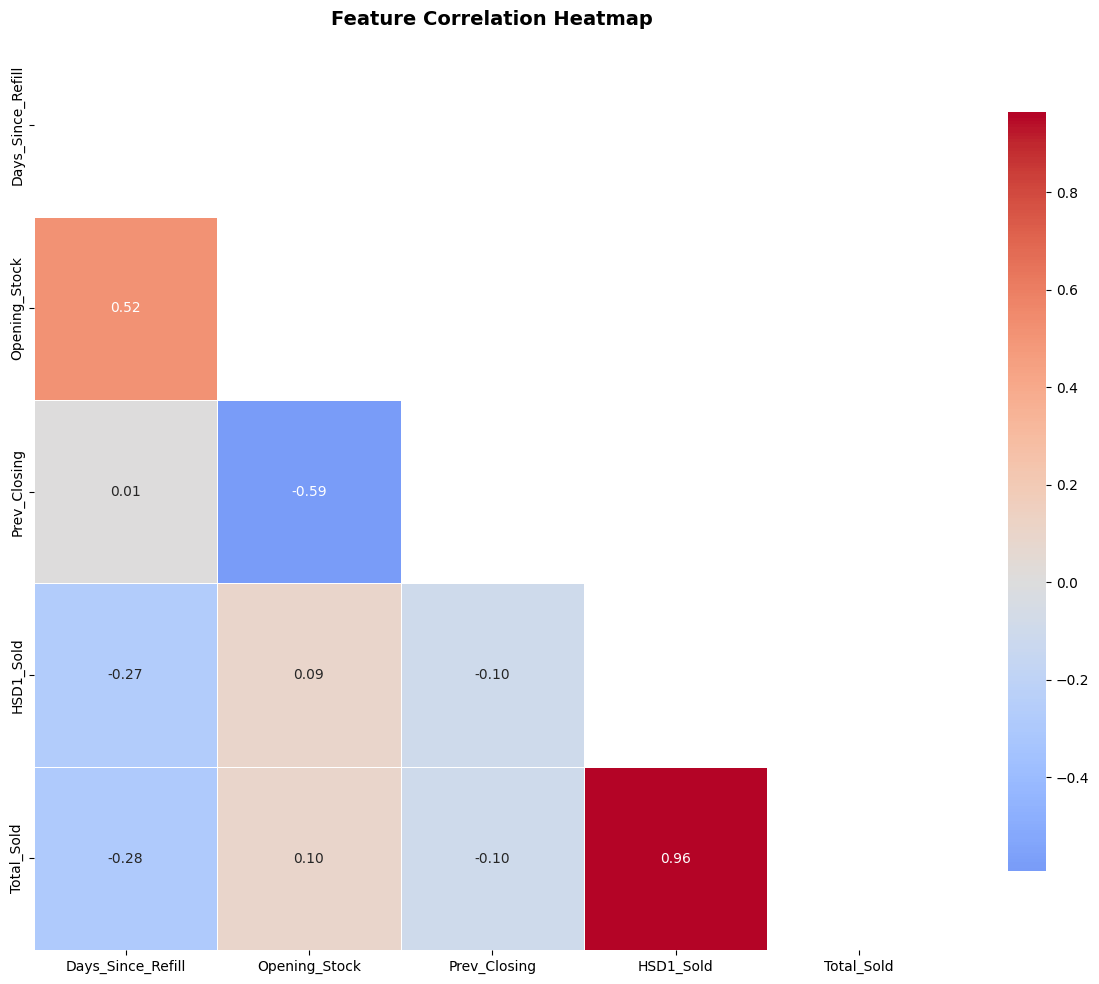

⚠️  Highly correlated pairs (>0.90) — consider dropping one from each pair:
   Total_Sold ↔ HSD1_Sold : 0.965


In [8]:
# Correlation matrix of selected features
corr_matrix = df[selected].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Find highly correlated pairs (> 0.90)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.90:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i,j]))

if high_corr:
    print('⚠️  Highly correlated pairs (>0.90) — consider dropping one from each pair:')
    for a, b, v in high_corr:
        print(f'   {a} ↔ {b} : {v:.3f}')
else:
    print('✅ No high multicollinearity found')

## Step 6 — Save Final Feature List

In [9]:
# Save selected features list for use in all other notebooks
feature_info = pd.DataFrame({
    'Feature': selected,
    'Importance': [importances[f] for f in selected],
    'Correlation_with_Target': [correlations.get(f, 0) for f in selected]
}).sort_values('Importance', ascending=False)

feature_info.to_csv('../data/selected_features.csv', index=False)

print('=== FINAL SELECTED FEATURES ===')
print(feature_info.to_string(index=False))
print(f'\nTotal features selected: {len(selected)}')
print('\n✅ Saved: data/selected_features.csv')
print('\nThese features will be used in all downstream notebooks.')

=== FINAL SELECTED FEATURES ===
          Feature  Importance  Correlation_with_Target
Days_Since_Refill    0.443165                -0.879473
    Opening_Stock    0.311060                -0.833206
     Prev_Closing    0.185348                 0.426924
        HSD1_Sold    0.011575                 0.144604
       Total_Sold    0.011554                 0.148655

Total features selected: 5

✅ Saved: data/selected_features.csv

These features will be used in all downstream notebooks.
